In [2]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS + PATH DETECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import os
from pathlib import Path
import json
import pandas as pd

# ============================================================
# USER INPUT: ONLY EDIT THIS ONE PATH
# ============================================================
kilosort_path = Path(r"G:\Kevin\2026-03-17_14-26-00\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4")  ##########################################################

# ============================================================
# UNIFIED SESSION ROOT + ANALYSIS FOLDER DETECTION
# ============================================================

def find_session_root(path):
    """
    Walk upward until we find a folder that contains at least one
    'Record Node ...' folder AND inside that folder an experiment*/recording* structure.
    """
    path = Path(path).resolve()

    while True:
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find valid session root.")

        # Look for Record Node folders
        record_nodes = [d for d in os.listdir(parent) if d.startswith("Record Node")]
        if len(record_nodes) > 0:
            # Check if any Record Node contains experiment*/recording*
            for rn in record_nodes:
                rn_path = parent / rn
                experiments = [d for d in os.listdir(rn_path) if d.startswith("experiment")]
                for exp in experiments:
                    exp_path = rn_path / exp
                    if (exp_path / "recording1").exists():
                        return parent

        path = parent

def build_analysis_folder(session_root):
    # session_root = .../2026-03-17_14-26-00
    session_date = session_root.name

    # Extract experiment and recording from kilosort_path
    # kilosort_path/.../experiment1/recording1/continuous/...
    parts = kilosort_path.parts
    experiment_name = next(p for p in parts if p.startswith("experiment"))
    recording_name = next(p for p in parts if p.startswith("recording"))

    folder_name = f"{session_date}_{experiment_name}_{recording_name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)

    subfolders = [
        "qc",
        "camera_alignment",
        "dlc_alignment",
        "behavior_ttls",
        "peak_detection",
        "metadata"
    ]
    for sf in subfolders:
        (analysis_folder / sf).mkdir(exist_ok=True)

    return analysis_folder


def get_analysis_folder_from_kilosort(kilosort_path):
    session_root = find_session_root(kilosort_path)
    return build_analysis_folder(session_root)

# Create analysis + QC folders
analysis_folder = get_analysis_folder_from_kilosort(kilosort_path)
qc_folder = analysis_folder / "qc"
qc_folder.mkdir(exist_ok=True)

print("Analysis folder:", analysis_folder)
print("QC folder:", qc_folder)


Analysis folder: G:\Kevin\2026-03-17_14-26-00\2026-03-17_14-26-00_experiment1_recording1_analysis
QC folder: G:\Kevin\2026-03-17_14-26-00\2026-03-17_14-26-00_experiment1_recording1_analysis\qc


In [4]:
# ============================================================
# CELL 1 — VERIFY + LOAD RECORDING
# ============================================================

raw_data_path = find_session_root(kilosort_path)

print("\n=== PATH VERIFICATION ===")
print("Session folder exists:", raw_data_path.is_dir())

record_nodes = [f for f in os.listdir(raw_data_path) if "Record Node" in f]
print("Record Nodes found:", record_nodes)

def find_experiment_name(path):
    path = Path(path).resolve()
    for part in path.parts:
        if part.startswith("experiment"):
            return part
    raise RuntimeError("Could not detect experiment name")

experiment_name = find_experiment_name(kilosort_path)
print("Detected experiment:", experiment_name)

print(f"\nLoading Neuropixels stream from experiment '{experiment_name}'...")
recording = si.read_openephys(
    raw_data_path,
    experiment_name=experiment_name,
    stream_id='1'
)
recording = si.scale(recording)

print("\nLoaded recording:")
print(recording)
print("Sampling rate:", recording.sampling_frequency)
print("Num channels:", recording.get_num_channels())



=== PATH VERIFICATION ===
Session folder exists: True
Record Nodes found: ['Record Node 114']
Detected experiment: experiment1

Loading Neuropixels stream from experiment 'experiment1'...

Loaded recording:
ScaleRecording: 384 channels - 30.0kHz - 1 segments - 31,858,792 samples 
                1,061.96s (17.70 minutes) - float32 dtype - 45.57 GiB
Sampling rate: 30000.0
Num channels: 384


In [5]:
# ============================================================
# CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION (run once)
# ============================================================

analyzer_path = qc_folder / "sorting_analyzer_output"
analyzer_path.mkdir(exist_ok=True)

print("\nAnalyzer output folder:", analyzer_path)

print("Loading sorting...")
sorting = si.read_kilosort(kilosort_path)

print("Creating analyzer...")

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording,
    folder=analyzer_path,
    format="binary_folder",
    overwrite=True
)

print("Computing FEATURES (run once)...")

analyzer.compute("random_spikes", max_spikes_per_unit=300)  ##########################################################
analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0)  ##########################################################
analyzer.compute("noise_levels")

print("Feature extraction complete and cached.")



Analyzer output folder: G:\Kevin\2026-03-17_14-26-00\2026-03-17_14-26-00_experiment1_recording1_analysis\qc\sorting_analyzer_output
Loading sorting...
Creating analyzer...


estimate_sparsity (no parallelization): 100%|██████████████████████████████████████| 1062/1062 [02:59<00:00,  5.91it/s]
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\spikeinterface\core\sortinganalyzer.py:371: UserWarning: Your sorting has spikes with samples times greater than your recording length. These spikes have been removed.
  warnings.warn(


Computing FEATURES (run once)...


noise_level (no parallelization): 100%|████████████████████████████████████████████████| 20/20 [00:02<00:00,  7.46it/s]

Feature extraction complete and cached.


In [7]:
# ============================================================
# CELL 3 — LOAD CACHED FEATURES (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Loading cached SpikeInterface features...")

wfs_ext = analyzer.get_extension("waveforms")
noise_ext = analyzer.get_extension("noise_levels")

noise = noise_ext.get_data()

ks_templates = np.load(kilosort_path / "templates.npy")
ks_channel_map = np.load(kilosort_path / "channel_map.npy")
cluster_info = pd.read_csv(kilosort_path / "cluster_info.tsv", sep="\t")

cluster_col = "cluster_id" if "cluster_id" in cluster_info.columns else "id"
channel_col = "ch" if "ch" in cluster_info.columns else "channel"

phy_best_ch_id = {
    int(row[cluster_col]): int(row[channel_col])
    for _, row in cluster_info.iterrows()
}

whitening_inv = np.load(kilosort_path / "whitening_mat_inv.npy")
ks_templates_unwhitened = np.einsum("ij,utj->uti", whitening_inv, ks_templates)

phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

print("\nAll features loaded successfully ✔️")


Loading cached SpikeInterface features...

All features loaded successfully ✔️


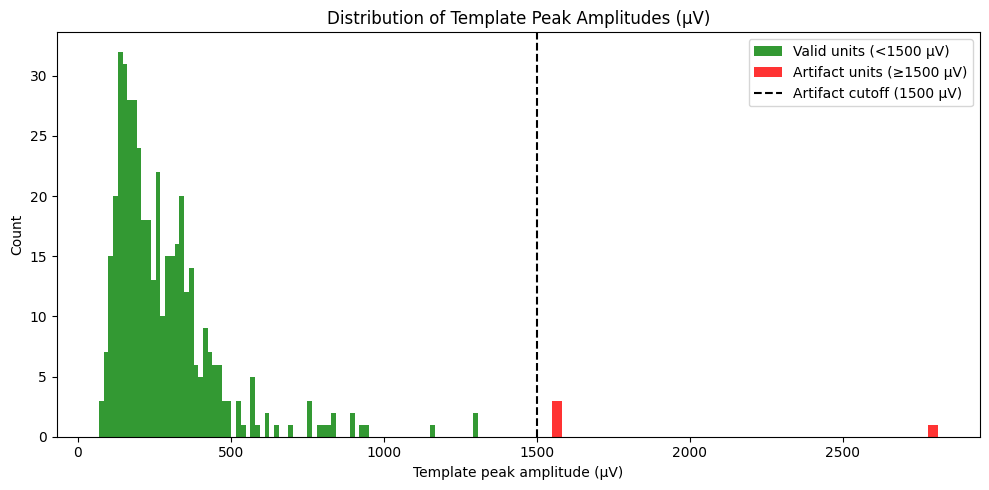


=== AMPLITUDE DISTRIBUTION SUMMARY ===
Total units: 439
Valid units (<1500 µV): 435
Artifact units (≥1500 µV): 4
Median amplitude (valid units): 232.72 µV
Max amplitude (valid units): 1307.36 µV

Artifact units (first 20): [np.int64(75), np.int64(153), np.int64(257), np.int64(406)] 


In [13]:
# ============================================================
# CELL 4 — AMPLITUDE DISTRIBUTION + ARTIFACT UNIT DETECTION (µV)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COMPUTE UNIT AMPLITUDES (µV) FROM UNWHITENED KS TEMPLATES
# ============================================================

unit_amp = {}

for uid in sorting.unit_ids:
    # template index = unit index in Kilosort order
    ks_idx = np.where(sorting.unit_ids == uid)[0][0]

    # get the unwhitened template for this unit
    temp = ks_templates_unwhitened[ks_idx]   # shape (samples, channels)

    # find the best channel from Phy
    best_ch_phys = phy_best_ch_id[uid]
    best_ch_idx = phys_to_template_index[best_ch_phys]

    # amplitude = peak-to-peak on best channel
    waveform = temp[:, best_ch_idx]
    amp_uv = waveform.max() - waveform.min()

    unit_amp[uid] = amp_uv

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
amp_cutoff_uv = 1500 ##########################################################
# ↑↑↑ Kevin edits this ONE value. Everything else depends on it.

# ------------------------------------------------------------
# BUILD AMPLITUDE ARRAY
# ------------------------------------------------------------
amps = np.array([unit_amp[uid] for uid in sorting.unit_ids])

# Masks
artifact_mask = amps >= amp_cutoff_uv
valid_mask = amps < amp_cutoff_uv

# Extract values
amps_valid = amps[valid_mask]
amps_artifact = amps[artifact_mask]

# ------------------------------------------------------------
# PLOT HISTOGRAM
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(amps_valid, bins=80, color='green', alpha=0.8,
         label=f'Valid units (<{amp_cutoff_uv} µV)')
if np.any(artifact_mask):
    plt.hist(amps_artifact, bins=40, color='red', alpha=0.8,
             label=f'Artifact units (≥{amp_cutoff_uv} µV)')

plt.axvline(amp_cutoff_uv, color='black', linestyle='--', linewidth=1.5,
            label=f'Artifact cutoff ({amp_cutoff_uv} µV)')

plt.xlabel("Template peak amplitude (µV)")
plt.ylabel("Count")
plt.title("Distribution of Template Peak Amplitudes (µV)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# UPDATE ARTIFACT + VALID UNIT LISTS FOR QC PIPELINE
# ------------------------------------------------------------
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]
valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\n=== AMPLITUDE DISTRIBUTION SUMMARY ===")
print(f"Total units: {len(amps)}")
print(f"Valid units (<{amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥{amp_cutoff_uv} µV): {len(artifact_units)}")

if len(amps_valid) > 0:
    print(f"Median amplitude (valid units): {np.median(amps_valid):.2f} µV")
    print(f"Max amplitude (valid units): {np.max(amps_valid):.2f} µV")
else:
    print("No valid units — all units exceed amplitude cutoff.")

print("\nArtifact units (first 20):", artifact_units[:20],
      "..." if len(artifact_units) > 20 else "")

# ------------------------------------------------------------
# MODULE OUTPUT: AMPLITUDE QC LABELS
# ------------------------------------------------------------
qc_amp = {
    uid: ("FAIL_AMP" if uid in artifact_units else "PASS_AMP")
    for uid in sorting.unit_ids
}


In [14]:
# ============================================================
# CELL 5 — PHY "Amplitude" FILTER USING cluster_info.tsv
# ============================================================

phy_amp_cutoff = 9.5  ##########################################################

cluster_info_path = kilosort_path / "cluster_info.tsv"

if not cluster_info_path.exists():
    raise FileNotFoundError(
        f"cluster_info.tsv not found in:\n{kilosort_path}\n"
        "Open this Kilosort folder in Phy and press Ctrl+S to generate it."
    )

ci = pd.read_csv(cluster_info_path, sep="\t")

# Build dict: unit_id → PHY amplitude
phy_amp_from_info = {
    int(row["id"]): float(row["Amplitude"])
    for _, row in ci.iterrows()
}

# Classify units
phy_valid_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) >= phy_amp_cutoff
]

phy_artifact_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) < phy_amp_cutoff
]

qc_phy_amp = {
    uid: ("FAIL_PHYAMP" if uid in phy_artifact_units else "PASS_PHYAMP")
    for uid in sorting.unit_ids
}

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n=== PHY Amplitude QC Summary ===")
print(f"Cutoff: {phy_amp_cutoff}")
print(f"Total units: {len(sorting.unit_ids)}")
print(f"PASS (Amplitude ≥ {phy_amp_cutoff}): {len(phy_valid_units)}")
print(f"FAIL (Amplitude < {phy_amp_cutoff}): {len(phy_artifact_units)}")

if len(phy_artifact_units) > 0:
    print("\nExample FAIL units:", phy_artifact_units[:15])
else:
    print("\nNo units failed PHY amplitude QC.")



=== PHY Amplitude QC Summary ===
Cutoff: 9.5
Total units: 439
PASS (Amplitude ≥ 9.5): 362
FAIL (Amplitude < 9.5): 77

Example FAIL units: [np.int64(1), np.int64(7), np.int64(9), np.int64(14), np.int64(26), np.int64(38), np.int64(41), np.int64(42), np.int64(57), np.int64(64), np.int64(77), np.int64(79), np.int64(82), np.int64(87), np.int64(92)]


In [16]:
# ============================================================
# CELL 6 — UNIFIED SHAPE QC: WIDTH + OSCILLATION
# ============================================================

sampling_rate = recording.sampling_frequency

min_width_ms = 0.13  ##########################################################
max_zerox = 4        ##########################################################
window_ms = 1.0      ##########################################################

unit_width_ms = {}
unit_zerox = {}
shape_artifact_units = []

win_samples = int(window_ms * sampling_rate / 1000)

for i, uid in enumerate(sorting.unit_ids):
    wf = ks_templates_unwhitened[i]
    neg_peaks = -np.min(wf, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    trace = wf[:, best_ch]

    # ---------------------------
    # WIDTH (half-minimum)
    # ---------------------------
    trough_idx = int(np.argmin(trace))
    trough_val = trace[trough_idx]
    half = trough_val / 2

    below = np.where(trace < half)[0]
    width_samples = (below[-1] - below[0]) if len(below) > 0 else 0
    width_ms = (width_samples / sampling_rate) * 1000
    unit_width_ms[uid] = width_ms

    # ---------------------------
    # OSCILLATION (zero-crossings)
    # ---------------------------
    start = max(0, trough_idx - win_samples // 2)
    end = min(len(trace), trough_idx + win_samples // 2)
    seg = trace[start:end] - np.mean(trace[start:end])
    signs = np.sign(seg)
    signs[signs == 0] = 1
    zerox = int(np.sum(signs[1:] != signs[:-1]))
    unit_zerox[uid] = zerox

    # ---------------------------
    # FAIL if width too small OR oscillation too high
    # ---------------------------
    if width_ms < min_width_ms or zerox > max_zerox:
        shape_artifact_units.append(uid)

qc_wave = {
    uid: ("FAIL_WAVE" if uid in shape_artifact_units else "PASS_WAVE")
    for uid in sorting.unit_ids
}

# ============================================================
# PRINT SUMMARY
# ============================================================

width_values = np.array(list(unit_width_ms.values()))
zerox_values = np.array(list(unit_zerox.values()))

fail_width_units = [uid for uid in sorting.unit_ids if unit_width_ms[uid] < min_width_ms]
fail_zerox_units = [uid for uid in sorting.unit_ids if unit_zerox[uid] > max_zerox]

print("\n=== SHAPE QC SUMMARY (WIDTH + OSCILLATION) ===")
print(f"Total units: {len(sorting.unit_ids)}")
print(f"Units failing WIDTH (<{min_width_ms} ms): {len(fail_width_units)}")
print(f"Units failing OSCILLATION (>{max_zerox} zero-crossings): {len(fail_zerox_units)}")
print(f"Units failing EITHER (1-of-2 rule): {len(shape_artifact_units)}")

print(f"\nMedian width: {np.median(width_values):.4f} ms")
print(f"Median zero-crossings: {np.median(zerox_values):.2f}")

print("\nExample WIDTH-fail units:", fail_width_units[:15])
print("Example OSC-fail units:", fail_zerox_units[:15])
print("Example ANY-fail units:", shape_artifact_units[:15])



=== SHAPE QC SUMMARY (WIDTH + OSCILLATION) ===
Total units: 439
Units failing WIDTH (<0.13 ms): 162
Units failing OSCILLATION (>4 zero-crossings): 45
Units failing EITHER (1-of-2 rule): 163

Median width: 0.1667 ms
Median zero-crossings: 2.00

Example WIDTH-fail units: [np.int64(12), np.int64(16), np.int64(19), np.int64(21), np.int64(28), np.int64(34), np.int64(37), np.int64(46), np.int64(47), np.int64(51), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(58)]
Example OSC-fail units: [np.int64(16), np.int64(21), np.int64(61), np.int64(66), np.int64(73), np.int64(74), np.int64(88), np.int64(96), np.int64(101), np.int64(103), np.int64(108), np.int64(109), np.int64(111), np.int64(119), np.int64(138)]
Example ANY-fail units: [np.int64(12), np.int64(16), np.int64(19), np.int64(21), np.int64(28), np.int64(34), np.int64(37), np.int64(46), np.int64(47), np.int64(51), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(58)]


Computing SNR and amplitude QC using Kilosort templates...

=== SNR FILTER RESULTS ===
SNR good units (≥ 3.5): 303
SNR bad units  (< 3.5): 113
SNR artifact units (> 31): 6

=== SNR QC SUMMARY (best channel) ===
Median noise (µV): 23.945323944091797
Median template peak (µV): 138.81634521484375
Median SNR: 5.711695270978369

First 5 units:
Unit 0: best_ch=3, amp=136.2 µV, noise=22.3 µV, SNR=6.11
Unit 1: best_ch=5, amp=49.0 µV, noise=22.5 µV, SNR=2.18
Unit 2: best_ch=5, amp=479.4 µV, noise=22.5 µV, SNR=21.31
Unit 3: best_ch=5, amp=184.2 µV, noise=22.5 µV, SNR=8.19
Unit 4: best_ch=7, amp=288.3 µV, noise=22.2 µV, SNR=13.01


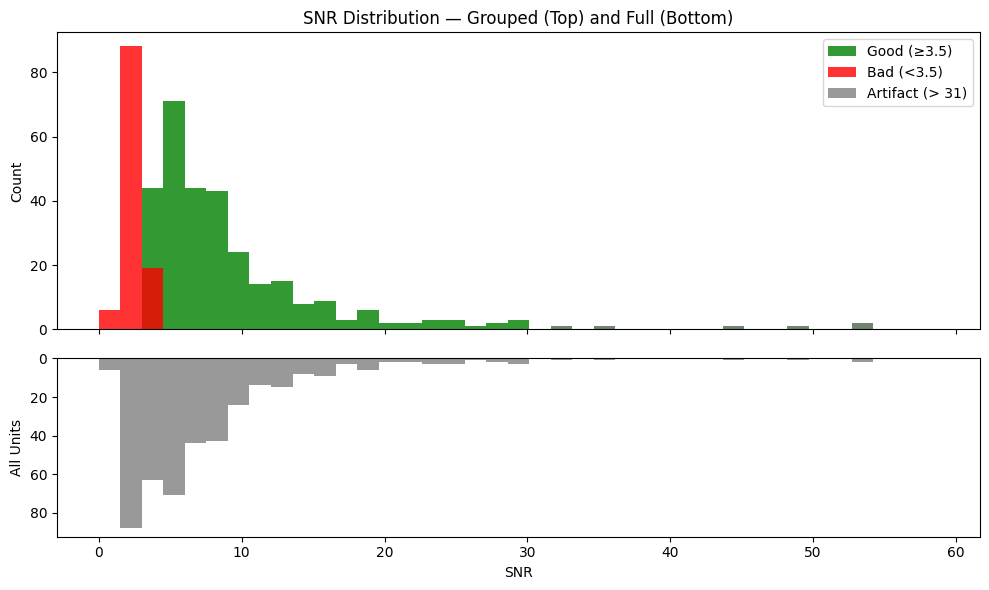

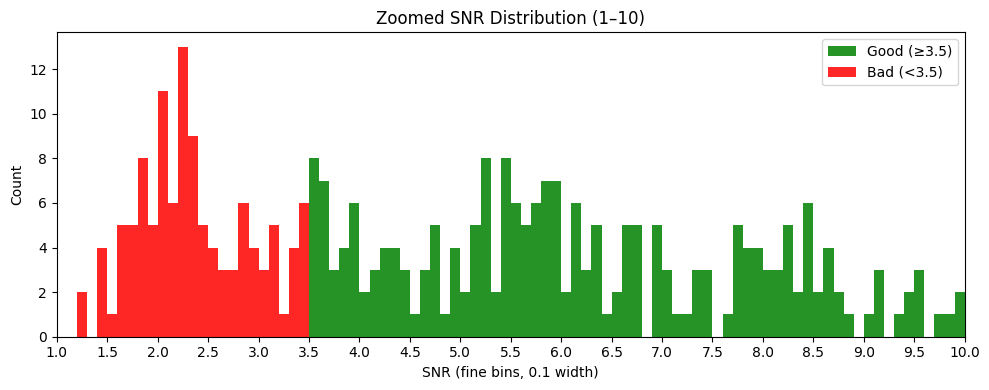


=== 10 UNITS AROUND MEDIAN SNR (median=5.71) ===
Unit 181: SNR=5.65, amp=143.4 µV, noise=25.4 µV, best_ch=142
Unit 140: SNR=5.68, amp=146.9 µV, noise=25.9 µV, best_ch=111
Unit 157: SNR=5.69, amp=151.0 µV, noise=26.6 µV, best_ch=126
Unit 182: SNR=5.69, amp=145.8 µV, noise=25.6 µV, best_ch=141
Unit 266: SNR=5.70, amp=141.9 µV, noise=24.9 µV, best_ch=223
Unit 50: SNR=5.72, amp=148.2 µV, noise=25.9 µV, best_ch=44
Unit 93: SNR=5.73, amp=134.2 µV, noise=23.4 µV, best_ch=79
Unit 63: SNR=5.73, amp=131.4 µV, noise=22.9 µV, best_ch=56
Unit 173: SNR=5.77, amp=155.3 µV, noise=26.9 µV, best_ch=132
Unit 264: SNR=5.80, amp=142.7 µV, noise=24.6 µV, best_ch=221


In [20]:
# ============================================================
# CELL 7 — SNR + TEMPLATE AMPLITUDE QC (KILOSORT TEMPLATES)
# ============================================================

print("Computing SNR and amplitude QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
snr_threshold = 3.5        ##########################################################
snr_artifact_cutoff = 31   ##########################################################
# ↑↑↑ Kevin edits these ONE TIME. Everything else depends on them.

# ------------------------------------------------------------
# COMPUTE TEMPLATE AMPLITUDE, NOISE, SNR
# ------------------------------------------------------------

unit_best_ch = {}
unit_amp2 = {}
unit_noise = {}
unit_snr = {}

for i, uid in enumerate(sorting.unit_ids):

    templ = ks_templates_unwhitened[i]    # <-- Kilosort template (unwhitened)

    # Best channel = most negative peak
    neg_peaks = -np.min(templ, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    neg_peak = float(neg_peaks[best_ch])

    # Noise from SI
    noise_best = float(noise[best_ch])
    snr = neg_peak / noise_best if noise_best > 0 else np.nan

    unit_best_ch[uid] = best_ch
    unit_amp2[uid] = neg_peak
    unit_noise[uid] = noise_best
    unit_snr[uid] = snr

# ------------------------------------------------------------
# CLASSIFY UNITS BY SNR
# ------------------------------------------------------------

snr_good_units = [uid for uid in sorting.unit_ids if unit_snr[uid] >= snr_threshold]
snr_bad_units  = [uid for uid in sorting.unit_ids if unit_snr[uid] <  snr_threshold]

# HARD ARTIFACTS: SNR TOO HIGH (template explosion)
snr_artifact_units = [uid for uid in sorting.unit_ids if unit_snr[uid] > snr_artifact_cutoff]

print("\n=== SNR FILTER RESULTS ===")
print(f"SNR good units (≥ {snr_threshold}): {len(snr_good_units)}")
print(f"SNR bad units  (< {snr_threshold}): {len(snr_bad_units)}")
print(f"SNR artifact units (> {snr_artifact_cutoff}): {len(snr_artifact_units)}")

# ------------------------------------------------------------
# SUMMARY STATISTICS
# ------------------------------------------------------------

amps_all = np.array(list(unit_amp2.values()))
snrs_all = np.array(list(unit_snr.values()))
noise_all = np.array(list(unit_noise.values()))

print("\n=== SNR QC SUMMARY (best channel) ===")
print("Median noise (µV):", float(np.median(noise_all)))
print("Median template peak (µV):", float(np.median(amps_all)))
print("Median SNR:", float(np.nanmedian(snrs_all)))

print("\nFirst 5 units:")
for uid in sorting.unit_ids[:5]:
    print(f"Unit {uid}: best_ch={unit_best_ch[uid]}, amp={unit_amp2[uid]:.1f} µV, "
          f"noise={unit_noise[uid]:.1f} µV, SNR={unit_snr[uid]:.2f}")

# ------------------------------------------------------------
# TWO-PART SNR HISTOGRAM
# ------------------------------------------------------------

snr_good = np.array([unit_snr[uid] for uid in snr_good_units])
snr_bad  = np.array([unit_snr[uid] for uid in snr_bad_units])
snr_art  = np.array([unit_snr[uid] for uid in snr_artifact_units])

snr_all = np.array([unit_snr[uid] for uid in sorting.unit_ids])

bins = np.linspace(0, max(snr_all) * 1.1, 40)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 0.6]}
)

ax_top.hist(snr_good, bins=bins, color='green', alpha=0.8, label=f'Good (≥{snr_threshold})')
ax_top.hist(snr_bad,  bins=bins, color='red',   alpha=0.8, label=f'Bad (<{snr_threshold})')
ax_top.hist(snr_art,  bins=bins, color='gray',  alpha=0.8, label=f'Artifact (> {snr_artifact_cutoff})')

ax_top.set_ylabel("Count")
ax_top.set_title("SNR Distribution — Grouped (Top) and Full (Bottom)")
ax_top.legend(loc='upper right')

ax_bottom.hist(snr_all, bins=bins, color='black', alpha=0.4)
ax_bottom.invert_yaxis()
ax_bottom.set_ylabel("All Units")
ax_bottom.set_xlabel("SNR")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ZOOMED SNR HISTOGRAM (1–10)
# ------------------------------------------------------------

bins = np.arange(1, 10.1, 0.1)

plt.figure(figsize=(10, 4))
plt.hist(snr_good, bins=bins, color='green', alpha=0.85, label=f'Good (≥{snr_threshold})')
plt.hist(snr_bad,  bins=bins, color='red',   alpha=0.85, label=f'Bad (<{snr_threshold})')

plt.xticks(np.arange(1, 11, 0.5))
plt.xlim(1, 10)

plt.xlabel("SNR (fine bins, 0.1 width)")
plt.ylabel("Count")
plt.title("Zoomed SNR Distribution (1–10)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================================
# UNITS AROUND THE MEDIAN SNR (FIXED: EXCLUDES NaNs)
# ============================================================

around_n = 10  ##########################################################

snr_list = [(uid, unit_snr[uid]) for uid in sorting.unit_ids if not np.isnan(unit_snr[uid])]
snr_values = np.array([s for _, s in snr_list])

median_snr_val = np.median(snr_values)

snr_sorted = sorted(snr_list, key=lambda x: x[1])

median_idx = min(
    range(len(snr_sorted)),
    key=lambda i: abs(snr_sorted[i][1] - median_snr_val)
)

start = max(0, median_idx - around_n // 2)
end = min(len(snr_sorted), start + around_n)

print(f"\n=== {end - start} UNITS AROUND MEDIAN SNR (median={median_snr_val:.2f}) ===")
for uid, snr_val in snr_sorted[start:end]:
    print(
        f"Unit {uid}: "
        f"SNR={snr_val:.2f}, "
        f"amp={unit_amp2[uid]:.1f} µV, "
        f"noise={unit_noise[uid]:.1f} µV, "
        f"best_ch={unit_best_ch[uid]}"
    )

# ------------------------------------------------------------
# MODULE OUTPUT: SNR QC LABELS
# ------------------------------------------------------------

qc_snr = {}

for uid in sorting.unit_ids:
    if uid in snr_artifact_units:
        qc_snr[uid] = "SKIP_SNR_ARTIFACT"
    elif uid in snr_bad_units:
        qc_snr[uid] = "FAIL_SNR"
    else:
        qc_snr[uid] = "PASS_SNR"


In [21]:
# ============================================================
# CELL 8 — POSITIVE DEFLECTION QC (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Computing positive deflection QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
pos_ratio_threshold = 0.4  ##########################################################
# Interpretation:
#   pos/neg ratio = 0.0 → perfectly negative spike (ideal)
#   pos/neg ratio = 0.3 → small positive bump (usually fine)
#   pos/neg ratio = 0.5 → moderate positive bump (borderline)
#   pos/neg ratio > 0.5 → large positive bump (often artifact)

# ------------------------------------------------------------
# COMPUTE POSITIVE / NEGATIVE PEAK RATIOS
# ------------------------------------------------------------

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        unit_pos_amp[uid] = 0.0
        unit_neg_amp[uid] = 0.0
        continue

    main_idx = phys_to_template_index[main_ch_id]
    trace = ks_templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_neg_amp[uid] = float(neg)
    unit_pos_amp[uid] = float(pos)
    unit_pos_ratio[uid] = float(pos / neg) if neg > 0 else np.inf

# ------------------------------------------------------------
# CLASSIFY UNITS BASED ON POSITIVE BUMP RATIO
# ------------------------------------------------------------

pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")

print("\nExample FAILED units (up to 15):")
if len(pos_bad_units) == 0:
    print("None")
else:
    print(pos_bad_units[:15])

# ------------------------------------------------------------
# MODULE OUTPUT: POSITIVE BUMP QC LABELS
# ------------------------------------------------------------

qc_pos = {}
for uid in sorting.unit_ids:
    qc_pos[uid] = "FAIL_POS" if uid in pos_bad_units else "PASS_POS"


Computing positive deflection QC using Kilosort templates...

=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.4): 235
GOOD units (pos/neg <  0.4): 204

Example FAILED units (up to 15):
[np.int64(1), np.int64(5), np.int64(7), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [22]:
# ============================================================
# CELL 9 — SLIM + SAFE ISI + ACG QC
# ============================================================

print("Computing ISI violations (RPV) using memory‑safe method...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
rp_ms = 2.0          ##########################################################
isi_threshold = 0.01  ##########################################################
# Interpretation:
#   rp_ms = refractory period (ms)
#   isi_threshold = fraction of ISIs < rp_ms that counts as FAIL

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
isi_metrics = {}
fs = recording.sampling_frequency

# ------------------------------------------------------------
# FUNCTION: refractory period violation rate
# ------------------------------------------------------------
def compute_rpv(st_sec, rp_ms=1.0):
    if st_sec.size < 2:
        return np.nan
    isis = np.diff(st_sec)
    return np.sum(isis < (rp_ms / 1000.0)) / len(isis)

# ------------------------------------------------------------
# LOOP THROUGH UNITS
# ------------------------------------------------------------
for uid in sorting.unit_ids:

    # Skip amplitude/SNR artifacts
    if uid in artifact_units:
        continue

    st_samples = sorting.get_unit_spike_train(uid)
    if st_samples.size < 2:
        isi_metrics[uid] = np.nan
        continue

    st_sec = st_samples / fs
    isi_metrics[uid] = compute_rpv(st_sec, rp_ms=rp_ms)

# ------------------------------------------------------------
# CLASSIFICATION
# ------------------------------------------------------------
good_isi_units = [uid for uid in isi_metrics if isi_metrics[uid] <  isi_threshold]
bad_isi_units  = [uid for uid in isi_metrics if isi_metrics[uid] >= isi_threshold]

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("\n=== ISI QC SUMMARY ===")
print(f"Good ISI units (<{isi_threshold*100:.1f}% RPV): {len(good_isi_units)}")
print(f"Bad ISI units (≥{isi_threshold*100:.1f}% RPV): {len(bad_isi_units)}")

print("\nFirst 5 ISI metrics:")
for uid in list(isi_metrics.keys())[:5]:
    print(f"Unit {uid}: RPV={isi_metrics[uid]:.4f}")

# ------------------------------------------------------------
# MODULE OUTPUT: ISI QC LABELS
# ------------------------------------------------------------
qc_isi = {}
for uid in sorting.unit_ids:
    if uid not in isi_metrics:
        qc_isi[uid] = "SKIP_ISI"
    elif np.isnan(isi_metrics[uid]):
        qc_isi[uid] = "SKIP_ISI"
    elif isi_metrics[uid] < isi_threshold:
        qc_isi[uid] = "PASS_ISI"
    else:
        qc_isi[uid] = "FAIL_ISI"


Computing ISI violations (RPV) using memory‑safe method...

=== ISI QC SUMMARY ===
Good ISI units (<1.0% RPV): 204
Bad ISI units (≥1.0% RPV): 122

First 5 ISI metrics:
Unit 0: RPV=0.0132
Unit 2: RPV=0.0316
Unit 3: RPV=0.0086
Unit 4: RPV=0.0013
Unit 6: RPV=0.0151


In [24]:
# ============================================================
# cell 10: FINAL QC TABLE + VERDICT (MODULAR)
# ============================================================

qc_rows = []

for uid in sorting.unit_ids:
    uid_int = int(uid)  # ensure Python int

    amp_label = qc_amp.get(uid_int, "NA_AMP")
    phy_label = qc_phy_amp.get(uid_int, "NA_PHYAMP")
    snr_label = qc_snr.get(uid_int, "NA_SNR")
    isi_label = qc_isi.get(uid_int, "NA_ISI")
    pos_label = qc_pos.get(uid_int, "NA_POS")
    wave_label = qc_wave.get(uid_int, "NA_WAVE")

    # Auto-fail rules
    if phy_label == "FAIL_PHYAMP":
        verdict = "REJECT"
        fail_count = "AUTO_FAIL_PHY"
    elif pos_label == "FAIL_POS":
        verdict = "REJECT"
        fail_count = "AUTO_FAIL_POS"
    else:
        labels = [amp_label, snr_label, isi_label, pos_label, wave_label]
        fail_count = sum(lbl.startswith("FAIL") for lbl in labels)
        verdict = "GOOD" if fail_count == 0 else ("CHECK" if fail_count == 1 else "REJECT")

    qc_rows.append({
        "unit": uid_int,
        "AMP": amp_label,
        "PHY_AMP": phy_label,
        "SNR": snr_label,
        "ISI": isi_label,
        "POS": pos_label,
        "WAVE": wave_label,
        "fail_count": fail_count,
        "verdict": verdict
    })

qc_df = pd.DataFrame(qc_rows).sort_values("unit").reset_index(drop=True)

print("\n=== FINAL QC VERDICT COUNTS ===")
print(qc_df["verdict"].value_counts())

qc_df.to_csv(qc_folder / "qc_table.csv", index=False)

# ------------------------------------------------------------
# FIX: convert all QC dict keys to Python int for JSON
# ------------------------------------------------------------
qc_labels_clean = {
    "qc_amp":      {int(k): v for k, v in qc_amp.items()},
    "qc_phy_amp":  {int(k): v for k, v in qc_phy_amp.items()},
    "qc_snr":      {int(k): v for k, v in qc_snr.items()},
    "qc_isi":      {int(k): v for k, v in qc_isi.items()},
    "qc_pos":      {int(k): v for k, v in qc_pos.items()},
    "qc_wave":     {int(k): v for k, v in qc_wave.items()},
}

with open(qc_folder / "qc_labels.json", "w") as f:
    json.dump(qc_labels_clean, f, indent=4)

print("\nQC saved to:", qc_folder)
print("QC MODULE COMPLETE ✔️")



=== FINAL QC VERDICT COUNTS ===
verdict
REJECT    269
CHECK     107
GOOD       63
Name: count, dtype: int64

QC saved to: G:\Kevin\2026-03-17_14-26-00\2026-03-17_14-26-00_experiment1_recording1_analysis\qc
QC MODULE COMPLETE ✔️


In [25]:
# ============================================================
# CELL 11 — REBUILD cluster_group.tsv FROM QC VERDICTS (CHECK → GOOD)
# ============================================================

import pandas as pd

cluster_group_path = kilosort_path / "cluster_group.tsv"

rows = []

for row in qc_df.itertuples():
    uid = int(row.unit)
    verdict = row.verdict

    # Map QC verdict → Phy label
    if verdict == "REJECT":
        group = "noise"      # Ctrl+N equivalent
    elif verdict == "CHECK":
        group = "good"       # CHECK now treated as GOOD
    elif verdict == "GOOD":
        group = "good"
    else:
        group = "good"

    rows.append({"cluster_id": uid, "group": group})

cg_new = pd.DataFrame(rows)
cg_new.to_csv(cluster_group_path, sep="\t", index=False)

print("Rebuilt cluster_group.tsv with", len(cg_new), "rows.")
print("CHECK units are now labeled as GOOD in Phy.")


Rebuilt cluster_group.tsv with 439 rows.
CHECK units are now labeled as GOOD in Phy.


In [26]:
# SINGLE UNIT CHECKER #

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
    else:
        print(row.to_string(index=False))
        
def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
        return
    
    r = row.iloc[0]
    print(f"Unit {unit_id} QC breakdown:")
    print(f"  AMP:       {r.AMP}")
    print(f"  PHY_AMP:   {r.PHY_AMP}")
    print(f"  SNR:       {r.SNR}")
    print(f"  ISI:       {r.ISI}")
    print(f"  POS:       {r.POS}")
    print(f"  Fail count:{r.fail_count}")
    print(f"  Verdict:   {r.verdict}")


show_qc_for_unit(119)

Unit 119 QC breakdown:
  AMP:       PASS_AMP
  PHY_AMP:   PASS_PHYAMP
  SNR:       PASS_SNR
  ISI:       PASS_ISI
  POS:       FAIL_POS
  Fail count:AUTO_FAIL_POS
  Verdict:   REJECT
